Group name: Stock Success
Created by Lexinejazly Asuncion (017077242), Pranavi Immanni (017207554), Anika Manjesh (017808479)

In [1]:
!pip install pandas seaborn matplotlib


[notice] A new release of pip is available: 23.1.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

## **Import Data and Preprocessing**

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Tech
apple_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/apple.csv'
nvidia_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/nvidia.csv'
microsoft_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/microsoft.csv'

# Defense
lockheed_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/lockheedmartin.csv'
northrop_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/northropgrumman.csv'
boeing_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/boeing.csv.zip'

# Waste Management
waste_mgt_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/wastemanagementinc.csv'
republic_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/republicservices.csv'
waste_conn_url = 'https://raw.githubusercontent.com/CS133-DataVisualization/term-project-stocksuccess/main/datasets/wasteconnections.csv'

In [4]:
url_list = {
    'AAPL': apple_url,
    'NVDA': nvidia_url,
    'MSFT': microsoft_url,
    'LMT': lockheed_url,
    'NOC': northrop_url,
    'BA': boeing_url,
    'WM': waste_mgt_url,
    'RSG': republic_url,
    'WCN': waste_conn_url
}

all_frames = []

rename_map = {
    'date': 'Date',
    'price': 'Close',
    'Price': 'Close',
    'Close/Last': 'Close',
    'close': 'Close',
    'open': 'Open',
    'high': 'High',
    'low': 'Low',
    'volume': 'Volume',
    'Vol.': 'Volume',
    'adj_close': 'Adj Close'
}

tech_tickers = ['AAPL', 'NVDA', 'MSFT']
defense_tickers = ['LMT', 'NOC', 'BA']
waste_tickers = ['WM', 'RSG', 'WCN']

#read csv files and store data into one dataframe
for name, url in url_list.items():
    df = pd.read_csv(url,
                     na_values=["-", ""])

    df.columns = [col.strip() for col in df.columns]

    df = df.rename(columns=rename_map)
    
    df['Date'] = pd.to_datetime(df['Date'], utc=True).dt.date

    df['Ticker'] = name

    #create column 'Industry' that specifies the industry
    if name in tech_tickers:
        df['Industry'] = 'Tech'
    elif name in defense_tickers:
        df['Industry'] = 'Defense'
    elif name in waste_tickers:
        df['Industry'] = 'Waste Management'

    #keep only the columns that exist in almost all sets
    standard_cols = ['Industry', 'Date', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume']
    df = df[standard_cols]

    all_frames.append(df)

#merge the dataframes into one
stocks = pd.concat(all_frames, ignore_index=True)

In [5]:
#clean 'Volume', 'Open', 'High', 'Low', and 'Close' columns
stocks['Volume'] = pd.to_numeric(stocks['Volume'].astype(str).str.replace('M', 'e6').str.replace('K', 'e3').str.replace('B', 'e9'), errors='coerce')

numeric_cols = ['Open', 'High', 'Low', 'Close']

for col in numeric_cols:
    stocks[col] = pd.to_numeric(
        stocks[col].astype(str).str.replace('$', '').str.replace(',', ''), errors='coerce')
     

In [6]:
stocks.head()

,Industry,Date,Ticker,Open,High,Low,Close,Volume
0,Tech,2025-09-26,AAPL,254.10,257.60,253.78,255.46,46080000.0
1,Tech,2025-09-25,AAPL,253.21,257.17,251.71,256.87,55200000.0
2,Tech,2025-09-24,AAPL,255.22,255.74,251.04,252.31,42300000.0
3,Tech,2025-09-23,AAPL,255.88,257.34,253.58,254.43,60280000.0
4,Tech,2025-09-22,AAPL,248.30,256.64,248.12,256.08,105520000.0


In [7]:
stocks.describe()

,Open,High,Low,Close,Volume
count,53011.000000,53011.000000,53011.000000,53011.000000,5.301000e+04
mean,91.936971,92.837901,91.026213,91.950703,1.187463e+08
std,118.605668,119.735844,117.456046,118.614944,2.814343e+08
min,0.060833,0.065667,0.060000,0.061417,7.290000e+04
25%,5.664032,5.728395,5.574074,5.656250,1.366203e+06
50%,43.920000,44.437500,43.312500,43.937500,3.732000e+06
75%,131.250000,132.430000,129.762500,131.135002,6.825630e+07
max,768.850000,774.000000,751.870000,768.020000,9.230856e+09


In [8]:
stocks.info()

<class 'pandas.DataFrame'>
RangeIndex: 53011 entries, 0 to 53010
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Industry  53011 non-null  str    
 1   Date      53011 non-null  object 
 2   Ticker    53011 non-null  str    
 3   Open      53011 non-null  float64
 4   High      53011 non-null  float64
 5   Low       53011 non-null  float64
 6   Close     53011 non-null  float64
 7   Volume    53010 non-null  float64
dtypes: float64(5), object(1), str(2)
memory usage: 3.2+ MB


There is missing data for one data entry in the stocks dataframe that corresponds to the Volume column. Since there is only one missing data point, we can remove it.

In [9]:
stocks[stocks['Volume'].isna()]

,Industry,Date,Ticker,Open,High,Low,Close,Volume
52964,Waste Management,2016-06-01,WCN,43.766,43.766,43.766,43.766,NaN


In [10]:
stocks.drop(index=52964, inplace=True)

In [11]:
stocks.info()

<class 'pandas.DataFrame'>
Index: 53010 entries, 0 to 53010
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Industry  53010 non-null  str    
 1   Date      53010 non-null  object 
 2   Ticker    53010 non-null  str    
 3   Open      53010 non-null  float64
 4   High      53010 non-null  float64
 5   Low       53010 non-null  float64
 6   Close     53010 non-null  float64
 7   Volume    53010 non-null  float64
dtypes: float64(5), object(1), str(2)
memory usage: 3.6+ MB


## **Exploratory Data Analysis**

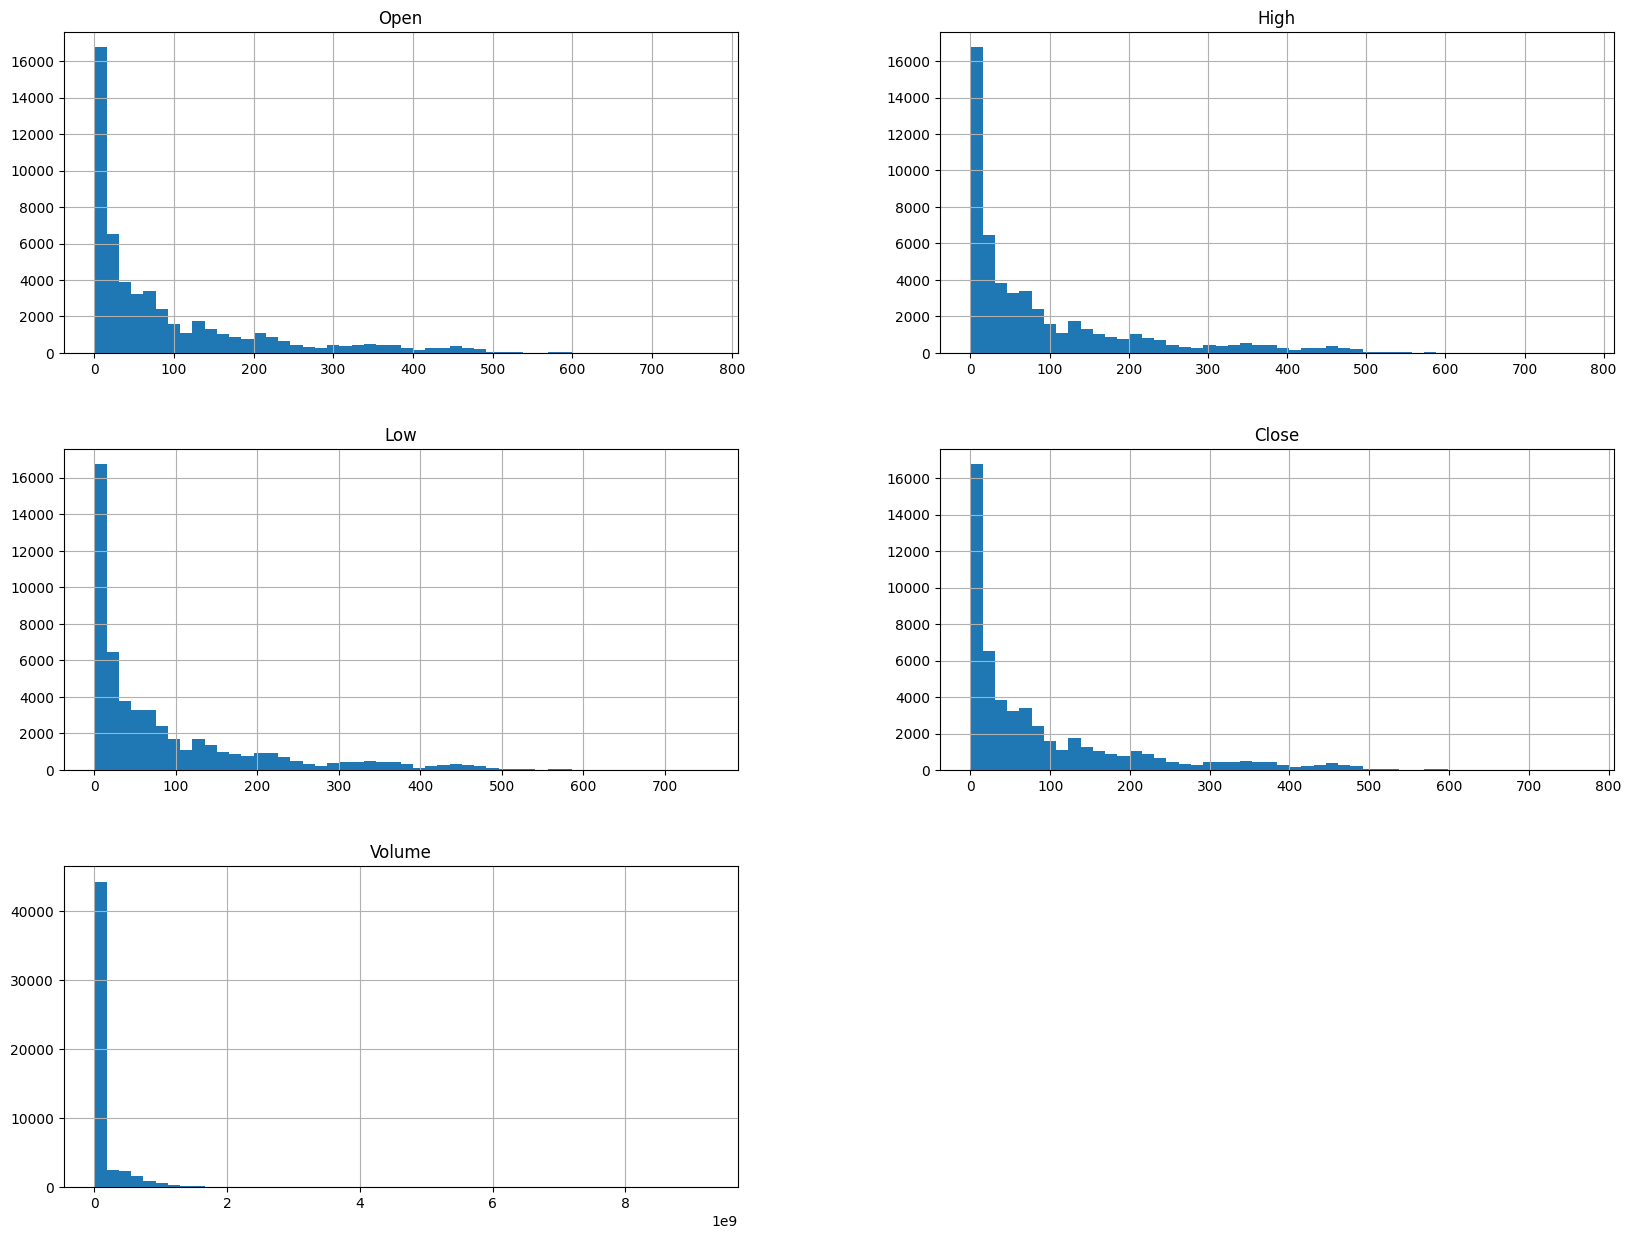

In [12]:
%matplotlib inline
import matplotlib.pyplot as plt
stocks.hist(bins=50, figsize=(20,15));

## **Interactive Plot**

# **Machine Learning**

Step 1

In [13]:
!pip install scikit-learn


[notice] A new release of pip is available: 23.1.2 -> 26.1
[notice] To update, run: pip install --upgrade pip


For our data, we are choosing to use regression models because classification models are for discrete data and our data is continuous.

In [14]:
stocks = stocks.sort_values(["Ticker", "Date"])

stocks["Return"] = stocks.groupby("Ticker")["Close"].pct_change()

# predict next day's return
stocks["Target"] = stocks.groupby("Ticker")["Return"].shift(-1)

In [15]:
stocks["Target"] = (stocks.groupby("Ticker")["Close"].pct_change().shift(-1) > 0).astype(int)

In [16]:
stocks["Date"] = pd.to_datetime(stocks["Date"], errors="coerce")
stocks = stocks.sort_values(["Ticker", "Date"]).reset_index(drop=True)

stocks["Return"] = stocks.groupby("Ticker")["Close"].pct_change()
stocks["MA_5"] = stocks.groupby("Ticker")["Close"].transform(lambda s: s.rolling(5).mean())
stocks["MA_20"] = stocks.groupby("Ticker")["Close"].transform(lambda s: s.rolling(20).mean())
stocks["Volatility_5"] = stocks.groupby("Ticker")["Return"].transform(lambda s: s.rolling(5).std())
stocks["Range"] = stocks["High"] - stocks["Low"]
stocks["Volume_Change"] = stocks.groupby("Ticker")["Volume"].pct_change()

# classification target: will tomorrow be positive?
stocks["Target"] = (stocks.groupby("Ticker")["Return"].shift(-1) > 0).astype(int)

stocks = stocks.dropna(subset=["Return", "MA_5", "MA_20", "Volatility_5", "Volume_Change"]).copy()

In [17]:
train = stocks[stocks["Date"] < pd.Timestamp("2020-01-01")].copy()
test  = stocks[stocks["Date"] >= pd.Timestamp("2020-01-01")].copy()

In [18]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_features = [
    "Open", "High", "Low", "Close", "Volume",
    "Return", "MA_5", "MA_20", "Volatility_5", "Range", "Volume_Change"
]
cat_features = ["Ticker", "Industry"]

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
])

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [20]:
pipelines = {
    name: Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

In [21]:
from sklearn.model_selection import cross_val_score

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, train[num_features + cat_features], train["Target"],
                             cv=5, scoring="f1")
    print(name)
    print("F1 scores:", scores)
    print("Mean F1:", scores.mean())
    print()

Logistic Regression
F1 scores: [0.33617092 0.00148552 0.40425253 0.61165387 0.66584036]
Mean F1: 0.40388063916118605

Decision Tree
F1 scores: [0.53309406 0.28584672 0.48723305 0.61390299 0.60655582]
Mean F1: 0.5053265299249909

Random Forest
F1 scores: [0.52665411 0.28919701 0.54280175 0.61096058 0.62406083]
Mean F1: 0.5187348572041282



Random Forest is found to be the best classification model for our purposes since it has the highest Mean F1 score. 

In [22]:
best_model = pipelines["Random Forest"] 
best_model.fit(train[num_features + cat_features], train["Target"])

y_test = test["Target"]
y_pred = best_model.predict(test[num_features + cat_features])
y_prob = best_model.predict_proba(test[num_features + cat_features])[:, 1]

In [23]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_prob))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.4981561648228315
Precision: 0.5259520884520884
Recall: 0.5190966959684753
F1: 0.5225019069412662
ROC AUC: 0.4954615504296018

Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.47      0.47      5876
           1       0.53      0.52      0.52      6598

    accuracy                           0.50     12474
   macro avg       0.50      0.50      0.50     12474
weighted avg       0.50      0.50      0.50     12474


Confusion Matrix:
[[2789 3087]
 [3173 3425]]


In [26]:
feature_cols_num = [
    "Open", "High", "Low", "Close", "Volume",
    "Return", "MA_5", "MA_20", "Volatility_5", "Range", "Volume_Change"
]

feature_cols_cat = ["Ticker", "Industry"]

X_train = train[feature_cols_num + feature_cols_cat]
y_train = train["Target"]

X_test = test[feature_cols_num + feature_cols_cat]
y_test = test["Target"]

In [27]:
best_model = pipelines["Random Forest"]

best_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [28]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [29]:
test_results = test.copy()
test_results["Predicted"] = y_pred
test_results["Prob_Up"] = y_prob

In [30]:
industry_summary = test_results.groupby("Industry").agg(
    Avg_Prob_Up=("Prob_Up", "mean"),
    Actual_Up_Rate=("Target", "mean")
).reset_index().sort_values("Avg_Prob_Up", ascending=False)

print(industry_summary)

           Industry  Avg_Prob_Up  Actual_Up_Rate
2  Waste Management     0.531140        0.541161
1              Tech     0.507203        0.532314
0           Defense     0.462122        0.509814


In [31]:
stock_summary = test_results.groupby(["Ticker", "Industry"]).agg(
    Avg_Prob_Up=("Prob_Up", "mean"),
    Actual_Up_Rate=("Target", "mean")
).reset_index().sort_values("Avg_Prob_Up", ascending=False)

print(stock_summary)

  Ticker          Industry  Avg_Prob_Up  Actual_Up_Rate
1     BA           Defense     0.559521        0.484507
0   AAPL              Tech     0.545700        0.529126
6    RSG  Waste Management     0.533708        0.555201
8     WM  Waste Management     0.531723        0.536056
7    WCN  Waste Management     0.527990        0.532227
3   MSFT              Tech     0.491604        0.523449
5   NVDA              Tech     0.480155        0.544961
2    LMT           Defense     0.444241        0.520699
4    NOC           Defense     0.408328        0.519464


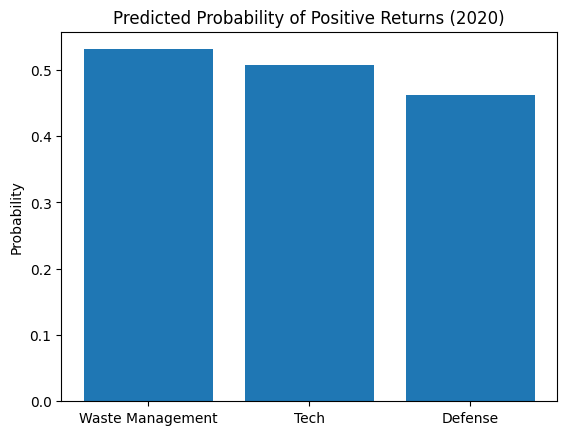

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(industry_summary["Industry"], industry_summary["Avg_Prob_Up"])
plt.title("Predicted Probability of Positive Returns (2020)")
plt.ylabel("Probability")
plt.show()

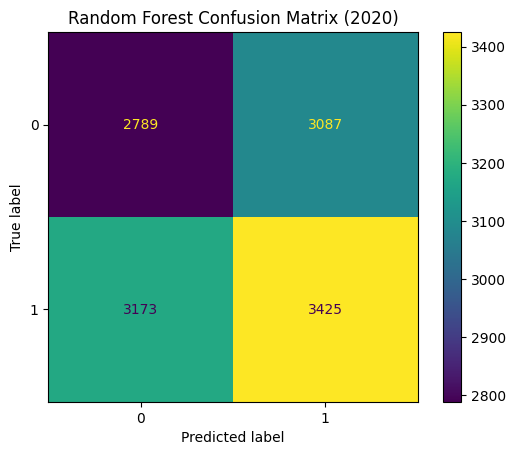

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Random Forest Confusion Matrix (2020)")
plt.show()

In [34]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.47      0.47      0.47      5876
           1       0.53      0.52      0.52      6598

    accuracy                           0.50     12474
   macro avg       0.50      0.50      0.50     12474
weighted avg       0.50      0.50      0.50     12474



In [35]:
worst_stocks = test_results.groupby("Ticker").agg(
    Avg_Return=("Return", "mean")
).sort_values("Avg_Return")

print(worst_stocks.head())

        Avg_Return
Ticker            
BA        0.000055
LMT       0.000303
WCN       0.000439
WM        0.000529
NOC       0.000587


In [36]:
before = stocks[stocks["Date"] < "2020-01-01"]
during = test
after = stocks[stocks["Date"] > "2020-12-31"]

In [37]:
before.groupby("Industry")["Return"].mean()
during.groupby("Industry")["Return"].mean()
after.groupby("Industry")["Return"].mean()

Industry
Defense             0.000471
Tech                0.001342
Waste Management    0.000542
Name: Return, dtype: float64

## **Evaluation**